In [1]:
using Jens
using Jens.LensMask
using Jens.LensSystem: ForwardModel, render, masked_logp
using Jens.LensModel: SIS, Shear
using Jens.LensModel.ComLens: CombinedLens
using Jens.LightModel: ExtendedSource, PointImages, CompositeImage
using Jens.LightModel.SersicLight: SersicSpheric
using Jens.LensPSF: GaussianPSF
using Jens.LensGenerator: LensedPlane, LightPlane, GenGrid
using Jens.LensNoise: GaussNoise, add_noise
using Jens.LensMH: lens_mh, chain
using Cosmology, Random, Statistics
using Jens:LensPlots as Jplots

In [2]:
cosmo  = Cosmology.FlatLCDM(0.7, 0.3, 0.0, 0.0)
z_lens = 0.3
z_src  = 1.5
sigma_data = 0.03
grid = GenGrid(pix_n=64, pix_size=0.08)

Jens.LensGenerator.Grid(64, 0.08, [-2.56 -2.56 … -2.56 -2.56; -2.48 -2.48 … -2.48 -2.48; … ; 2.48 2.48 … 2.48 2.48; 2.56 2.56 … 2.56 2.56], [-2.56 -2.48 … 2.48 2.56; -2.56 -2.48 … 2.48 2.56; … ; -2.56 -2.48 … 2.48 2.56; -2.56 -2.48 … 2.48 2.56])

In [3]:
lens = LensedPlane(
    CombinedLens(
        SIS   => (theta_E=1.2, xcentre=0.0, ycentre=0.0),
        Shear => (gamma1=0.05, gamma2=-0.03),
    ); z_lens=z_lens, cosmology=cosmo)

LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64}}}, Cosmology.FlatLCDM{Float64}}(CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64}}}((Jens.LensModel.SIS, Jens.LensModel.Shear), ((theta_E = 1.2, xcentre = 0.0, ycentre = 0.0), (gamma1 = 0.05, gamma2 = -0.03))), 0.3, Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0))

In [4]:
host = ExtendedSource(SersicSpheric;
    amp=8.0, Rsersic=0.3, n=2.0, xcentre=0.03, ycentre=-0.02)

agn_pos = [(x, y) for (x, y, _) in
    Jens.LensSolver.solve_images(lens, 0.04, -0.03; z_source=z_src)]
agn = PointImages((8.0, agn_pos); intrinsic=true)

src = LightPlane(CompositeImage(host, agn); z=z_src)

LightPlane{CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}}(CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}((ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}(Jens.LightModel.SersicLight.SersicSpheric, (amp = 8.0, Rsersic = 0.3, n = 2.0, xcentre = 0.03, ycentre = -0.02)), PointImages{Float64}([(8.0, [(0.9745025228030478, -0.4073012400643143), (-0.17242517626780388, 0.881023931625045)])], true))), 1.5)

In [5]:
mask = combine(
    annular_mask(grid, 0.5, 2.0),         
    invert(circular_mask(grid, 0.2));   
    op=&,
);

In [6]:
lens_sys = ForwardModel(lens_plane=lens, source_plane=src, grid=grid,
                          psf=GaussianPSF(fwhm=0.06),mask=mask) 


ForwardModel{LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64}}}, Cosmology.FlatLCDM{Float64}}, LightPlane{CompositeImage{Tuple{ExtendedSource{typeof(SersicSpheric), @NamedTuple{amp::Float64, Rsersic::Float64, n::Float64, xcentre::Float64, ycentre::Float64}}, PointImages{Float64}}}}, GaussianPSF{Float64}, Jens.LensGenerator.Grid, BitMatrix}(LensedPlane{CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64}}}, Cosmology.FlatLCDM{Float64}}(CombinedLens{Tuple{Module, Module}, Tuple{@NamedTuple{theta_E::Float64, xcentre::Float64, ycentre::Float64}, @NamedTuple{gamma1::Float64, gamma2::Float64}}}((Jens.LensModel.SIS, Jens.LensModel.Shear), ((theta_E = 1.2, xcentre = 0.0, ycentre = 0.0), (gamma1 = 0.05, gamma2 = -0.03))), 0.3, Cosmology.FlatLCDM{Float64}(0.7, 0.3, 0.0, 0.0)), Li

In [7]:
img = render(lens_sys);

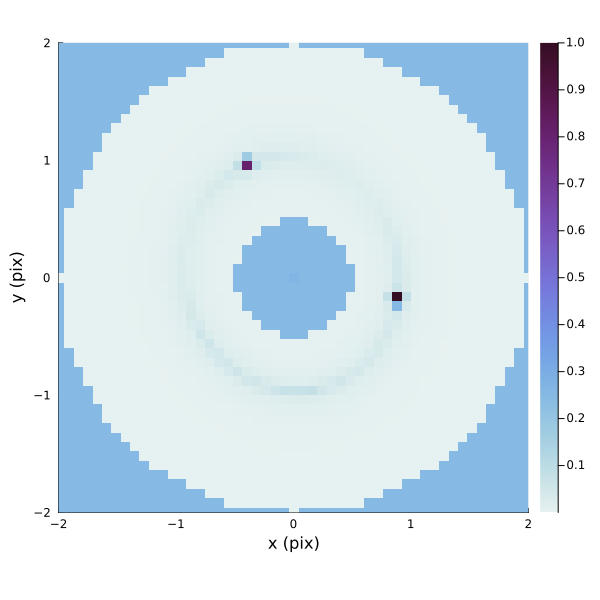

In [ ]:
canvas = Jplots.LensCanvas(xlims=(-2,2), ylims=(-2,2))
rgb = overlay_mask(render(lens_sys), lens_sys.mask; color=:grey, alpha=0.5)
Jplots.PlotPlane!(canvas, rgb[:,:,1]; pixel_scale=0.08)

In [ ]:
logp = masked_logp(lens_sys, img, sigma_data) # including the mask

-0.0

# Costum mask

In [13]:
user_mask = ones(Int, 17, 17)           
user_mask[1:5, 1:5] .= 0              
user_mask[end-2:end, end-2:end] .= 0  
mask = from_matrix(user_mask)

17×17 BitMatrix:
 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1
 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1
 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1
 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1
 0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  0  0  0
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  0  0  0
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  0  0  0